In [1]:
import numpy as np
import fmm2dpy as fmm
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import configure, configure_eval, _field_mt
from hypermagnetics.fmm_sources import potential2D

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

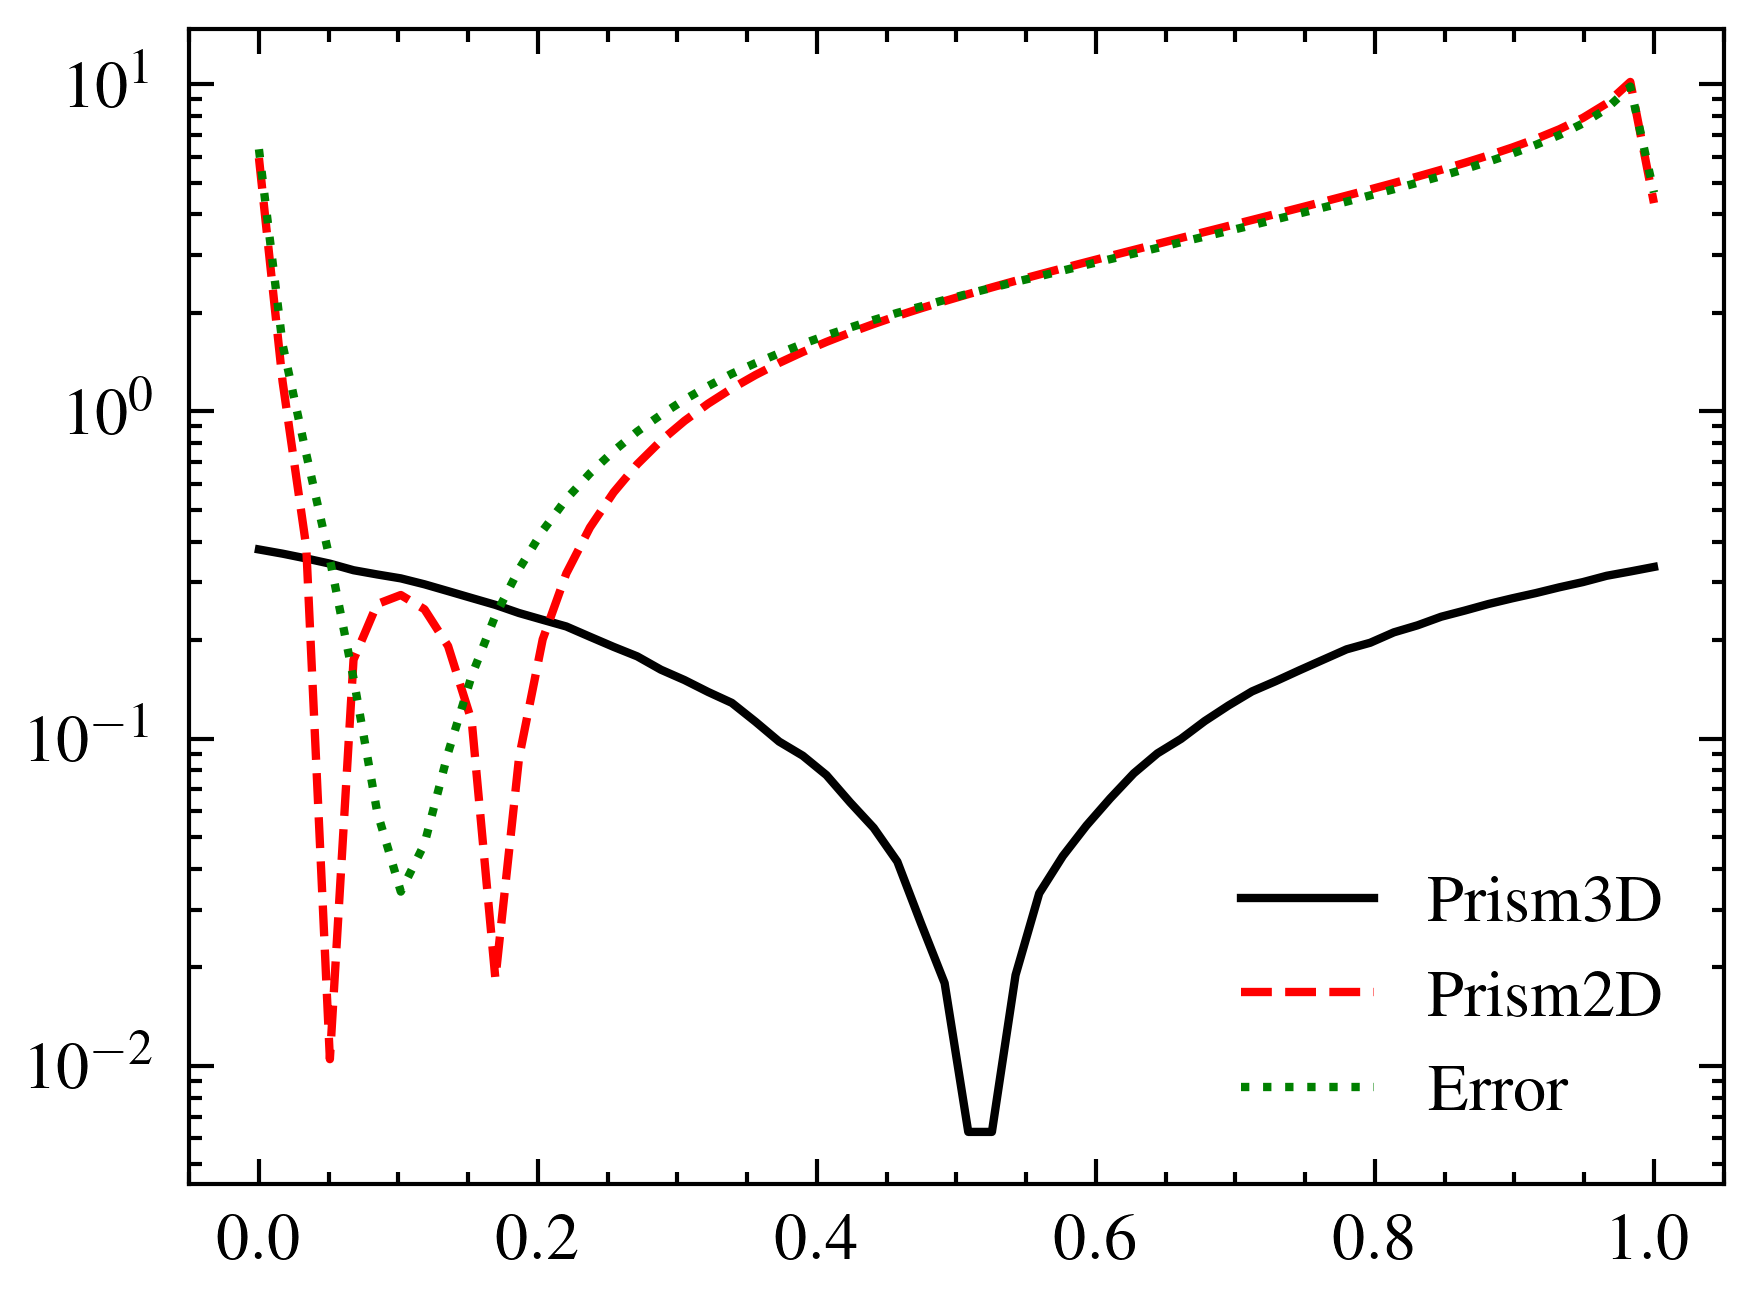

In [2]:
cfg_pr = {
    "n_samples": 1,
    "lim": 1,
    "res": 60,
    "shape": "prism",
    "line": True,
    "eps": 0.1,
    "quadtree": True,
}
train_3d = configure(**cfg_pr, n_sources=12, seed=0)

cfg_pr["calc_2d"] = True
train_pr = configure(**cfg_pr, n_sources=12, seed=0)

if not cfg_pr["line"]:
    print("2D")
    plots(train_pr, shapes=True)
    print("3D")
    plots(train_3d, shapes=True)
else:
    # Only necessary for line plots
    plt.plot(train_3d['grid'][:, 0], np.abs(train_3d["potential_grid"][0]))
    plt.plot(train_pr['grid'][:, 0], np.abs(train_pr["potential_grid"][0]), color='red', linestyle='--')
    plt.plot(train_pr['grid'][:, 0], np.abs(train_pr["potential_grid"][0] - train_3d["potential_grid"][0]), color='green', linestyle=':')


    plt.yscale("log")
    # plt.xlim(5,15)
    plt.legend(["Prism3D", "Prism2D", "Error"])

0.046393003


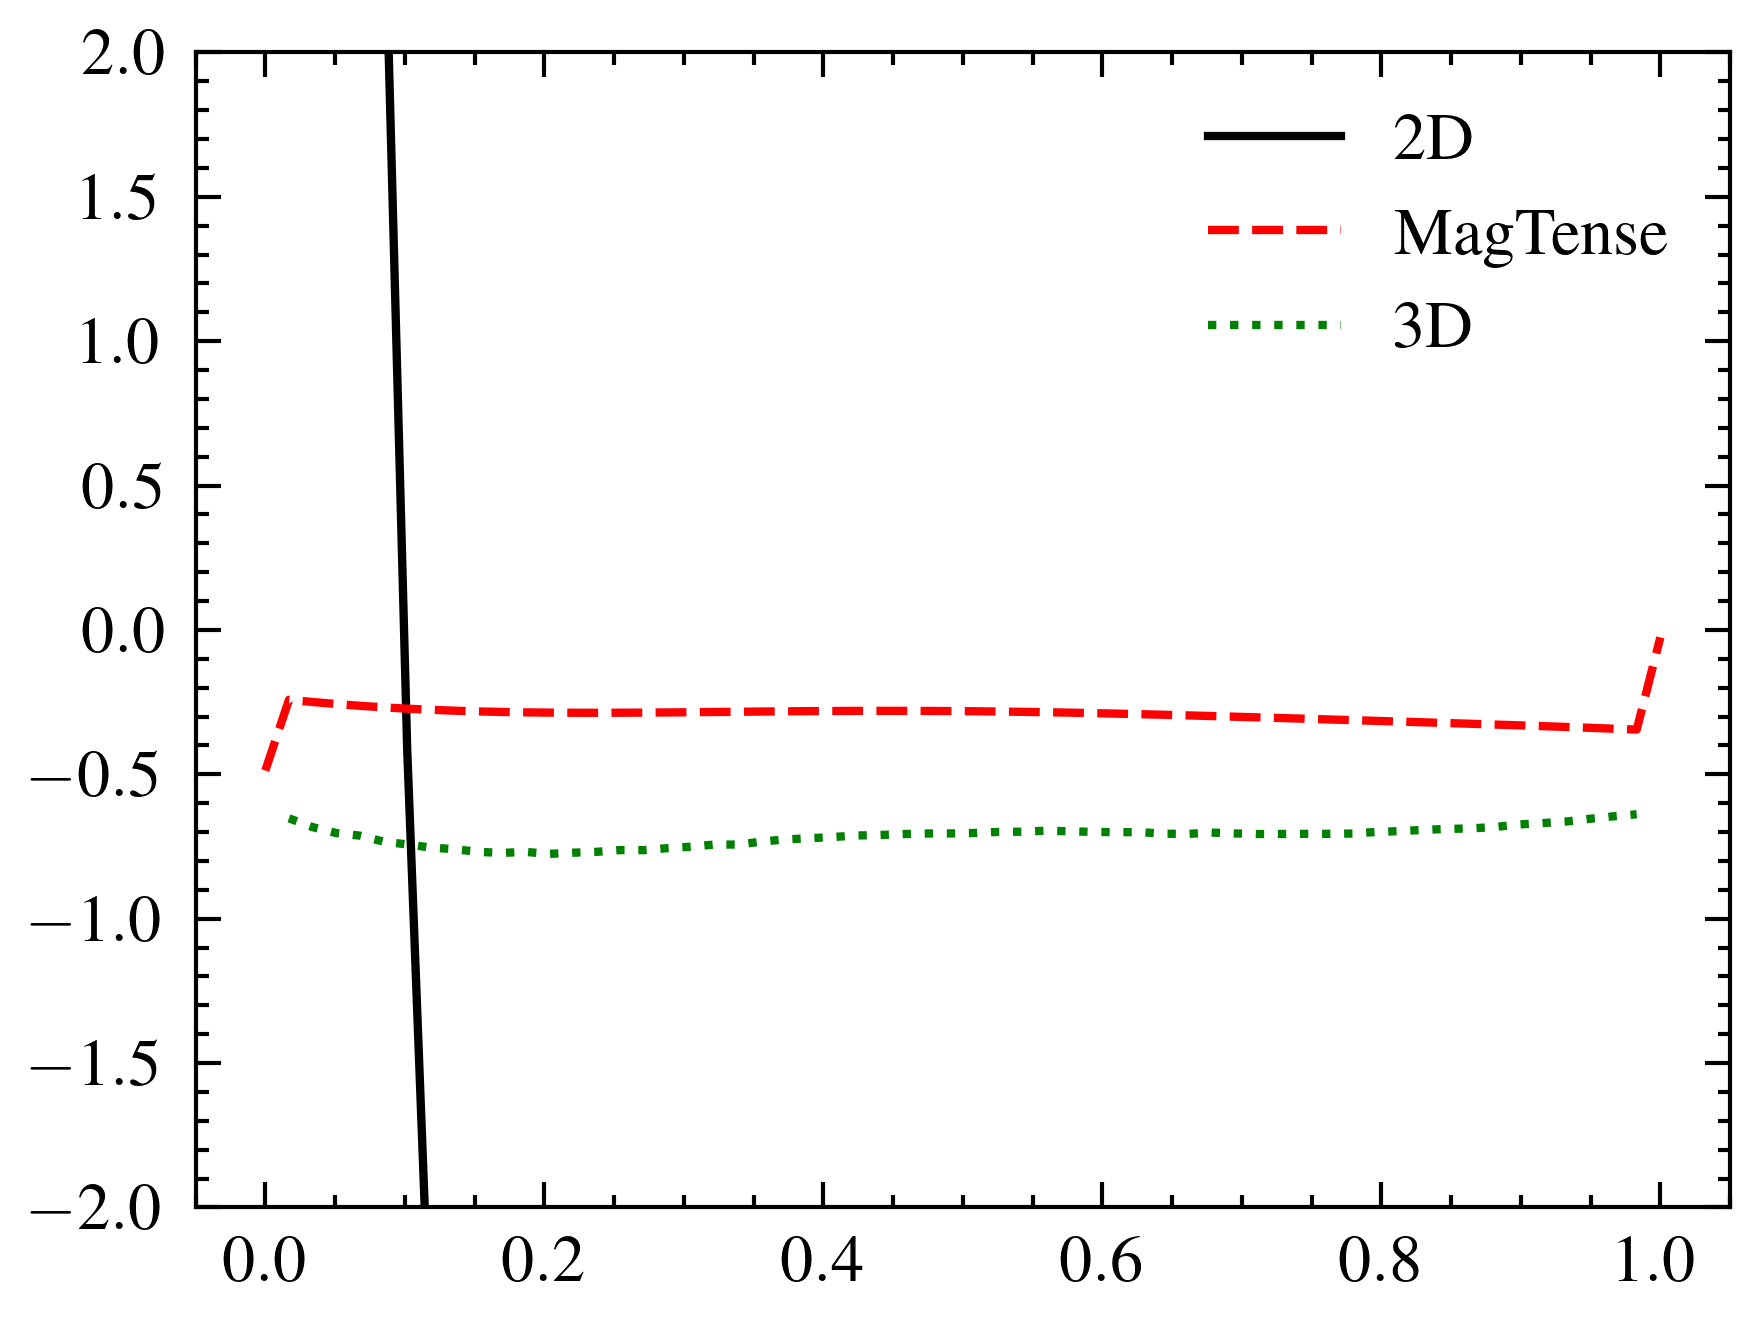

In [5]:
mt_sim, _ = _field_mt(train_3d['sources'], train_3d['grid'], "prism")

if cfg_pr["line"]:
    plt.plot(train_pr['grid'][:, 0], train_pr["field_grid"][0, ..., 0])
    plt.plot(train_3d['grid'][:, 0], mt_sim[0, ..., 0], color='red', linestyle='--')
    plt.plot(train_3d['grid'][:, 0], train_3d["field_grid"][0, ..., 0], color='green', linestyle=':')
    # plt.plot(train_3d['grid'][:, 0], mt_sim[0, ..., 0] / train_pr["field_grid"][0, ..., 0], color='green', linestyle=':')
    # plt.yscale("log")
    # plt.xlim(5,15)
    plt.ylim(-2, 2)
    plt.legend(["2D", "MagTense", "3D"])
    print(np.nanmean(np.abs(mt_sim[0, :, 0] / train_pr["field_grid"][0, :, 0])))